# Análisis elecciones presidenciales Colombianas del 2018

## Primera vuelta

Proyecto de portafolio orientado al análisis exploratorio y territorial de los resultados electorales.

### Objetivos

- Revisar la calidad y estructura del dataset.
- Separar candidatos de categorías electorales.
- Calcular votos absolutos y porcentajes.
- Analizar resultados nacionales, departamentales y municipales.
- Calcular márgenes de victoria.
- Identificar municipios con patrones atípicos.
- Exportar visualizaciones para el README y el portafolio.
- Preparar los datos para un dashboard interactivo.

## 1. Importación de librerías y configuración

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Rutas del proyecto

El código busca la raíz del proyecto desde el notebook. De esta forma, puede ejecutarse tanto desde VS Code como desde Jupyter.

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "2018_presidencia_primera_vuelta.dta.csv"
IMAGES_PATH = PROJECT_ROOT / "images"
IMAGES_PATH.mkdir(exist_ok=True)

DATA_PATH

WindowsPath('d:/Sartocol87/Documentos/debsenior/ejercicios/elecciones/colombia-election-analysis-2018/data/2018_presidencia_primera_vuelta.dta.csv')

## 3. Carga y exploración inicial

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 12,725
Columnas: 16


,id_electoral,ano,tipo_eleccion,fecha_eleccion,coddpto,departamento,codmpio,municipio,circunscripcion,codigo_partido,codigo_lista,primer_apellido,segundo_apellido,nombres,votos,curules
0,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,"20,180,003.00",1,PETRO,URREGO,GUSTAVO FRANCISCO,77067,1
1,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,"20,180,004.00",2,NaN,NaN,PROMOTORES VOTO EN BLANCO,1847,0
2,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,"20,130,001.00",3,DUQUE,MARQUEZ,IVAN,535239,1
3,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,"20,180,002.00",4,DE LA CALLE,LOMBANA,HUMBERTO,25896,0
4,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,"20,170,002.00",5,TRUJILLO,SARMIENTO,JORGE ANTONIO,2197,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12725 entries, 0 to 12724
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_electoral      12725 non-null  int64  
 1   ano               12725 non-null  int64  
 2   tipo_eleccion     12725 non-null  object 
 3   fecha_eleccion    12725 non-null  object 
 4   coddpto           12725 non-null  int64  
 5   departamento      12725 non-null  object 
 6   codmpio           12725 non-null  int64  
 7   municipio         12725 non-null  object 
 8   circunscripcion   12725 non-null  object 
 9   codigo_partido    9284 non-null   float64
 10  codigo_lista      12725 non-null  int64  
 11  primer_apellido   11629 non-null  object 
 12  segundo_apellido  8188 non-null   object 
 13  nombres           9284 non-null   object 
 14  votos             12725 non-null  int64  
 15  curules           12725 non-null  int64  
dtypes: float64(1), int64(7), object(8)
memor

In [5]:
df.isna().sum().sort_values(ascending=False)

segundo_apellido    4537
codigo_partido      3441
nombres             3441
primer_apellido     1096
id_electoral           0
ano                    0
tipo_eleccion          0
fecha_eleccion         0
coddpto                0
departamento           0
codmpio                0
municipio              0
circunscripcion        0
codigo_lista           0
votos                  0
curules                0
dtype: int64

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_electoral,"12,725.00",NaN,NaN,NaN,"120,180,001.00",0.00,"120,180,001.00","120,180,001.00","120,180,001.00","120,180,001.00","120,180,001.00"
ano,"12,725.00",NaN,NaN,NaN,"2,018.00",0.00,"2,018.00","2,018.00","2,018.00","2,018.00","2,018.00"
tipo_eleccion,12725,1,Presidencia,12725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_eleccion,12725,1,Mayo 27,12725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coddpto,"12,725.00",NaN,NaN,NaN,36.76,26.40,5.00,15.00,25.00,63.00,99.00
departamento,12725,34,ANTIOQUIA,1374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codmpio,"12,725.00",NaN,NaN,NaN,"37,188.62","26,386.35","5,001.00","15,401.00","25,612.00","63,272.00","99,773.00"
municipio,12725,1102,VILLANUEVA,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
circunscripcion,12725,1,Nacional,12725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codigo_partido,"9,284.00",NaN,NaN,NaN,"20,172,382.34","16,569.39","20,130,001.00","20,180,001.00","20,180,002.00","20,180,004.00","20,180,006.00"


### Observación inicial

Los valores faltantes en nombres y códigos de partido no deben eliminarse automáticamente. Algunas filas corresponden a votos nulos, tarjetas no marcadas, voto en blanco u otras categorías que no representan una candidatura individual.

## 4. Preparación y clasificación de registros

In [7]:
# Construcción del nombre completo.
df["candidato"] = (
    df["primer_apellido"].fillna("") + " "
    + df["segundo_apellido"].fillna("") + " "
    + df["nombres"].fillna("")
).str.replace(r"\s+", " ", regex=True).str.strip()

df[["primer_apellido", "segundo_apellido", "nombres", "candidato"]].head()

,primer_apellido,segundo_apellido,nombres,candidato
0,PETRO,URREGO,GUSTAVO FRANCISCO,PETRO URREGO GUSTAVO FRANCISCO
1,NaN,NaN,PROMOTORES VOTO EN BLANCO,PROMOTORES VOTO EN BLANCO
2,DUQUE,MARQUEZ,IVAN,DUQUE MARQUEZ IVAN
3,DE LA CALLE,LOMBANA,HUMBERTO,DE LA CALLE LOMBANA HUMBERTO
4,TRUJILLO,SARMIENTO,JORGE ANTONIO,TRUJILLO SARMIENTO JORGE ANTONIO


In [8]:
# Categorías electorales que no representan candidatos.
SPECIAL_CATEGORIES = {
    "VOTOS EN BLANCO": "Voto en blanco",
    "PROMOTORES VOTO EN BLANCO": "Voto en blanco",
    "VOTOS NULOS": "Voto nulo",
    "TARJETAS NO MARCADAS": "Tarjeta no marcada",
}

df["tipo_registro"] = (
    df["candidato"]
    .map(SPECIAL_CATEGORIES)
    .fillna("Candidato")
)

df[["candidato", "tipo_registro"]].drop_duplicates().sort_values(
    ["tipo_registro", "candidato"]
)

,candidato,tipo_registro
3,DE LA CALLE LOMBANA HUMBERTO,Candidato
2,DUQUE MARQUEZ IVAN,Candidato
5,FAJARDO VALDERRAMA SERGIO,Candidato
6,MORALES HOYOS VIVIANE ALEIDA,Candidato
0,PETRO URREGO GUSTAVO FRANCISCO,Candidato
4,TRUJILLO SARMIENTO JORGE ANTONIO,Candidato
7,VARGAS LLERAS GERMAN,Candidato
8,TARJETAS NO MARCADAS,Tarjeta no marcada
1,PROMOTORES VOTO EN BLANCO,Voto en blanco
10,VOTOS EN BLANCO,Voto en blanco


## 5. Resultado nacional

Primero se calculan los votos de todas las categorías. Después se construye una tabla exclusiva de candidatos para evitar mezclar candidaturas con votos nulos, blancos o tarjetas no marcadas.

In [9]:
national_results = (
    df.groupby(["candidato", "tipo_registro"], as_index=False)["votos"]
    .sum()
    .sort_values("votos", ascending=False)
)

national_results

,candidato,tipo_registro,votos
1,DUQUE MARQUEZ IVAN,Candidato,7617114
4,PETRO URREGO GUSTAVO FRANCISCO,Candidato,4854831
2,FAJARDO VALDERRAMA SERGIO,Candidato,4602916
8,VARGAS LLERAS GERMAN,Candidato,1412392
0,DE LA CALLE LOMBANA HUMBERTO,Candidato,396151
9,VOTOS EN BLANCO,Voto en blanco,338581
10,VOTOS NULOS,Voto nulo,242002
7,TRUJILLO SARMIENTO JORGE ANTONIO,Candidato,65767
6,TARJETAS NO MARCADAS,Tarjeta no marcada,47675
3,MORALES HOYOS VIVIANE ALEIDA,Candidato,36138


In [10]:
candidate_results = (
    national_results[national_results["tipo_registro"] == "Candidato"]
    .copy()
)

total_candidate_votes = candidate_results["votos"].sum()
candidate_results["porcentaje"] = (
    candidate_results["votos"] / total_candidate_votes * 100
)

candidate_results

,candidato,tipo_registro,votos,porcentaje
1,DUQUE MARQUEZ IVAN,Candidato,7617114,40.12
4,PETRO URREGO GUSTAVO FRANCISCO,Candidato,4854831,25.57
2,FAJARDO VALDERRAMA SERGIO,Candidato,4602916,24.24
8,VARGAS LLERAS GERMAN,Candidato,1412392,7.44
0,DE LA CALLE LOMBANA HUMBERTO,Candidato,396151,2.09
7,TRUJILLO SARMIENTO JORGE ANTONIO,Candidato,65767,0.35
3,MORALES HOYOS VIVIANE ALEIDA,Candidato,36138,0.19


### Interpretación

El porcentaje se calcula sobre los votos asignados a candidatos. Las demás categorías se analizan por separado para evitar denominadores ambiguos.

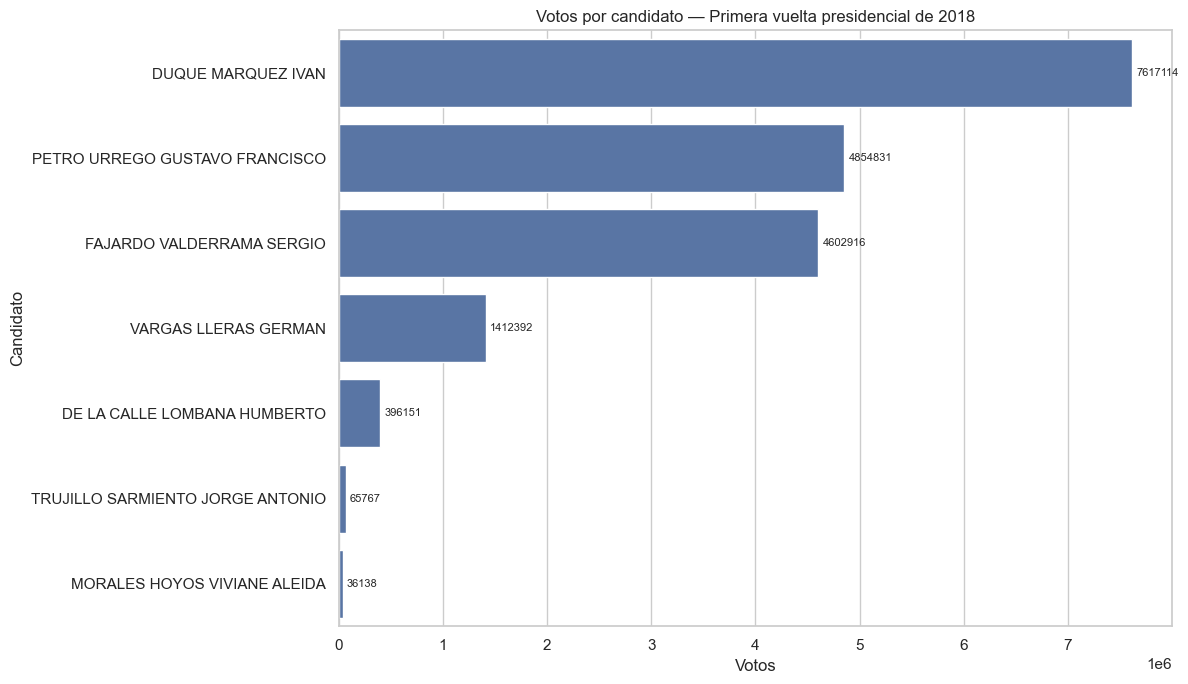

In [11]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=candidate_results,
    x="votos",
    y="candidato"
)

ax.set_title("Votos por candidato — Primera vuelta presidencial de 2018")
ax.set_xlabel("Votos")
ax.set_ylabel("Candidato")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_PATH / "01_votos_por_candidato.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Categorías no asociadas a candidatos

In [12]:
special_results = (
    national_results[national_results["tipo_registro"] != "Candidato"]
    .copy()
)

total_all_records = national_results["votos"].sum()
special_results["porcentaje_total"] = (
    special_results["votos"] / total_all_records * 100
)

special_results

,candidato,tipo_registro,votos,porcentaje_total
9,VOTOS EN BLANCO,Voto en blanco,338581,1.72
10,VOTOS NULOS,Voto nulo,242002,1.23
6,TARJETAS NO MARCADAS,Tarjeta no marcada,47675,0.24
5,PROMOTORES VOTO EN BLANCO,Voto en blanco,30128,0.15


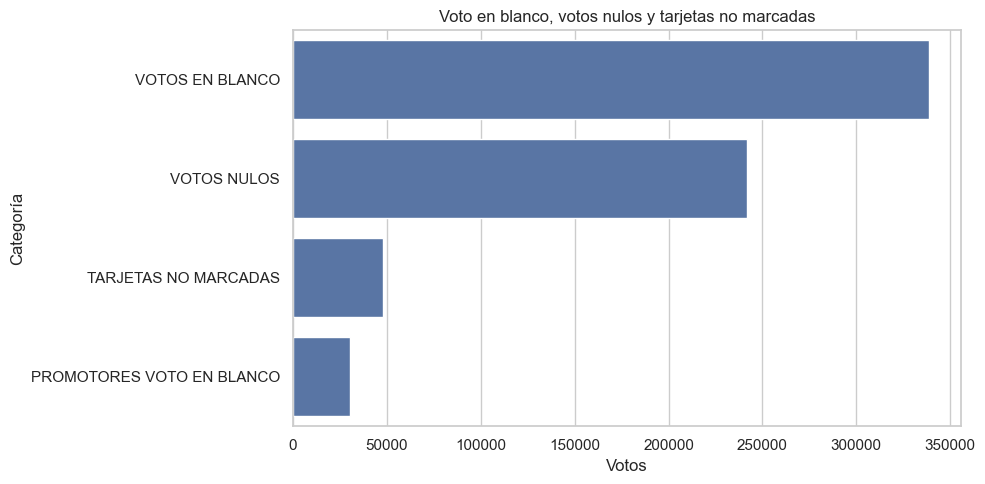

In [13]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=special_results,
    x="votos",
    y="candidato"
)
ax.set_title("Voto en blanco, votos nulos y tarjetas no marcadas")
ax.set_xlabel("Votos")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.savefig(IMAGES_PATH / "02_categorias_electorales.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Departamentos con mayor volumen electoral

In [14]:
department_votes = (
    df.groupby("departamento", as_index=False)["votos"]
    .sum()
    .sort_values("votos", ascending=False)
)

department_votes.head(10)

,departamento,votos
5,BOGOTA DC,3705960
1,ANTIOQUIA,2615238
31,VALLE DEL CAUCA,1780994
16,CUNDINAMARCA,1208999
28,SANTANDER,1004596
4,ATLANTICO,873397
6,BOLIVAR,638517
24,NORTE DE SANTANDER,626915
15,CORDOBA,597614
30,TOLIMA,584488


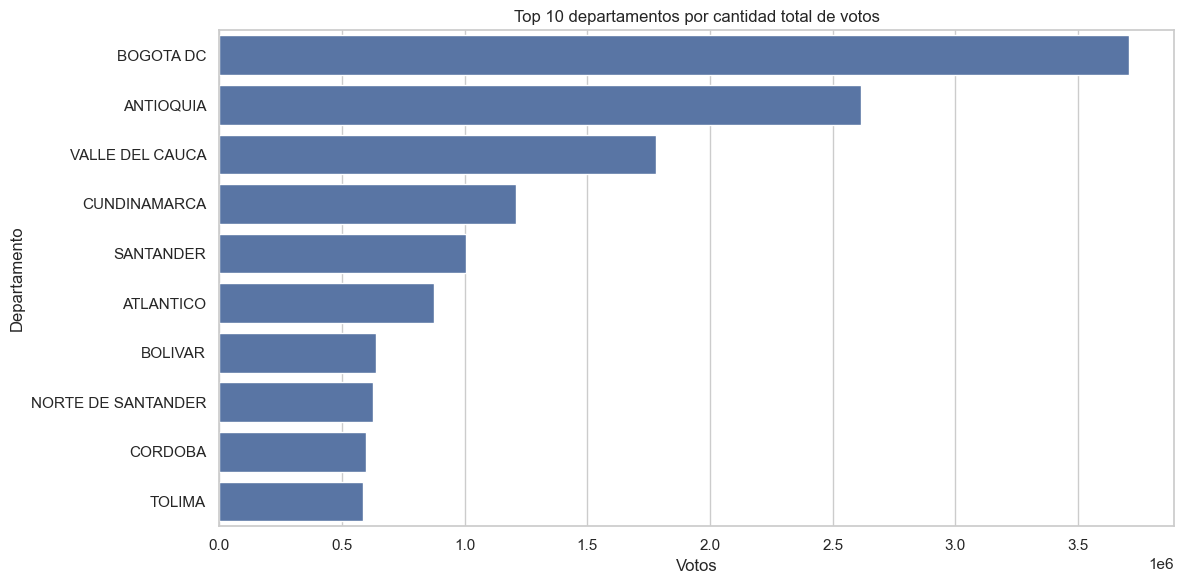

In [15]:
top_departments = department_votes.head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_departments,
    x="votos",
    y="departamento"
)
ax.set_title("Top 10 departamentos por cantidad total de votos")
ax.set_xlabel("Votos")
ax.set_ylabel("Departamento")
plt.tight_layout()
plt.savefig(IMAGES_PATH / "03_top_departamentos.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Ganador y margen de victoria por departamento

In [16]:
department_candidate = (
    df[df["tipo_registro"] == "Candidato"]
    .groupby(["departamento", "candidato"], as_index=False)["votos"]
    .sum()
)

department_ranked = department_candidate.sort_values(
    ["departamento", "votos"],
    ascending=[True, False]
)

department_ranked["posicion"] = (
    department_ranked.groupby("departamento").cumcount() + 1
)

top_two_department = department_ranked[
    department_ranked["posicion"].isin([1, 2])
].copy()

top_two_department.head(10)

,departamento,candidato,votos,posicion
1,AMAZONAS,DUQUE MARQUEZ IVAN,7104,1
4,AMAZONAS,PETRO URREGO GUSTAVO FRANCISCO,5931,2
8,ANTIOQUIA,DUQUE MARQUEZ IVAN,1375965,1
9,ANTIOQUIA,FAJARDO VALDERRAMA SERGIO,732993,2
15,ARAUCA,DUQUE MARQUEZ IVAN,49721,1
18,ARAUCA,PETRO URREGO GUSTAVO FRANCISCO,17814,2
22,ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA...,DUQUE MARQUEZ IVAN,5691,1
25,ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA...,PETRO URREGO GUSTAVO FRANCISCO,2361,2
32,ATLANTICO,PETRO URREGO GUSTAVO FRANCISCO,331979,1
29,ATLANTICO,DUQUE MARQUEZ IVAN,236291,2


In [17]:
department_pivot = (
    top_two_department
    .pivot(index="departamento", columns="posicion", values=["candidato", "votos"])
)

department_margins = pd.DataFrame({
    "departamento": department_pivot.index,
    "ganador": department_pivot[("candidato", 1)].values,
    "segundo": department_pivot[("candidato", 2)].values,
    "votos_ganador": department_pivot[("votos", 1)].astype(float).values,
    "votos_segundo": department_pivot[("votos", 2)].astype(float).values,
})

department_margins["margen_votos"] = (
    department_margins["votos_ganador"]
    - department_margins["votos_segundo"]
)

department_margins["margen_porcentual"] = (
    department_margins["margen_votos"]
    / (
        department_margins["votos_ganador"]
        + department_margins["votos_segundo"]
    )
    * 100
)

department_margins.sort_values("margen_porcentual").head(10)

,departamento,ganador,segundo,votos_ganador,votos_segundo,margen_votos,margen_porcentual
31,VALLE DEL CAUCA,DUQUE MARQUEZ IVAN,FAJARDO VALDERRAMA SERGIO,"527,622.00","502,367.00","25,255.00",2.45
6,BOLIVAR,DUQUE MARQUEZ IVAN,PETRO URREGO GUSTAVO FRANCISCO,"258,540.00","242,471.00","16,069.00",3.21
27,RISARALDA,DUQUE MARQUEZ IVAN,FAJARDO VALDERRAMA SERGIO,"177,523.00","165,882.00","11,641.00",3.39
15,CORDOBA,PETRO URREGO GUSTAVO FRANCISCO,DUQUE MARQUEZ IVAN,"250,437.00","229,234.00","21,203.00",4.42
20,LA GUAJIRA,PETRO URREGO GUSTAVO FRANCISCO,DUQUE MARQUEZ IVAN,"85,523.00","76,549.00","8,974.00",5.54
26,QUINDIO,DUQUE MARQUEZ IVAN,FAJARDO VALDERRAMA SERGIO,"109,631.00","98,078.00","11,553.00",5.56
5,BOGOTA DC,FAJARDO VALDERRAMA SERGIO,PETRO URREGO GUSTAVO FRANCISCO,"1,244,477.00","1,099,955.00","144,522.00",6.16
21,MAGDALENA,DUQUE MARQUEZ IVAN,PETRO URREGO GUSTAVO FRANCISCO,"161,863.00","142,945.00","18,918.00",6.21
8,CALDAS,DUQUE MARQUEZ IVAN,FAJARDO VALDERRAMA SERGIO,"191,910.00","162,448.00","29,462.00",8.31
29,SUCRE,PETRO URREGO GUSTAVO FRANCISCO,DUQUE MARQUEZ IVAN,"154,801.00","129,976.00","24,825.00",8.72


### Lectura del margen

Un margen pequeño indica una competencia cerrada entre las dos candidaturas más votadas. Un margen elevado sugiere dominio territorial del ganador.

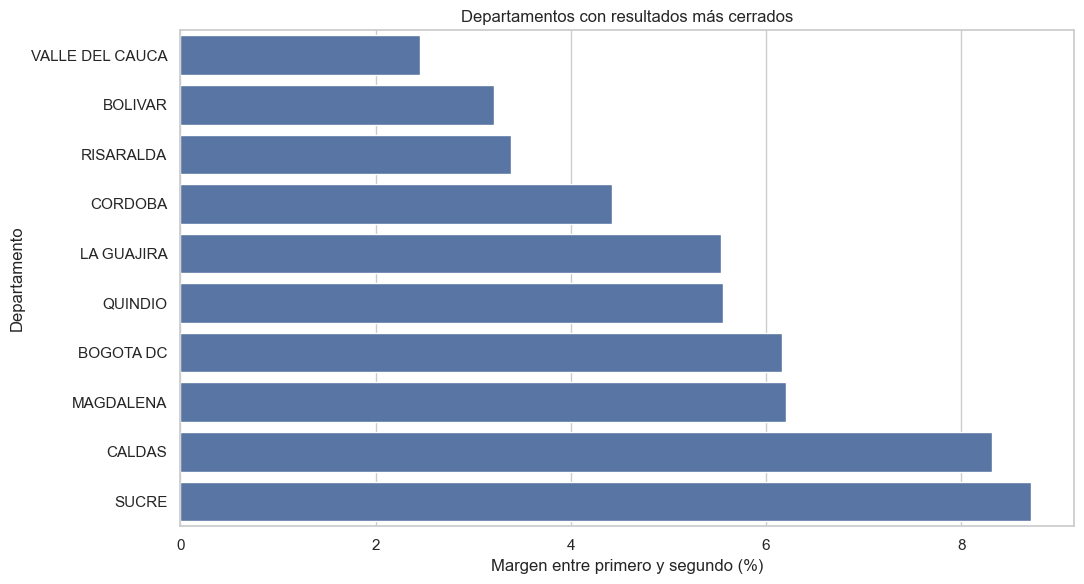

In [18]:
closest_departments = (
    department_margins
    .sort_values("margen_porcentual")
    .head(10)
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=closest_departments,
    x="margen_porcentual",
    y="departamento"
)
ax.set_title("Departamentos con resultados más cerrados")
ax.set_xlabel("Margen entre primero y segundo (%)")
ax.set_ylabel("Departamento")
plt.tight_layout()
plt.savefig(IMAGES_PATH / "04_departamentos_mas_cerrados.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Municipios con mayor cantidad de votos

In [19]:
municipality_votes = (
    df.groupby(["departamento", "municipio"], as_index=False)["votos"]
    .sum()
    .sort_values("votos", ascending=False)
)

municipality_votes.head(10)

,departamento,municipio,votos
168,BOGOTA DC,BOGOTA DC,3705960
79,ANTIOQUIA,MEDELLIN,1009878
1147,VALLE DEL CAUCA,CALI,883217
146,ATLANTICO,BARRANQUILLA,501970
931,NORTE DE SANTANDER,SAN JOSE DE CUCUTA,320722
987,SANTANDER,BUCARAMANGA,306948
177,BOLIVAR,CARTAGENA DE INDIAS,304264
1113,TOLIMA,IBAGUE,255315
974,RISARALDA,PEREIRA,234395
834,META,VILLAVICENCIO,225253


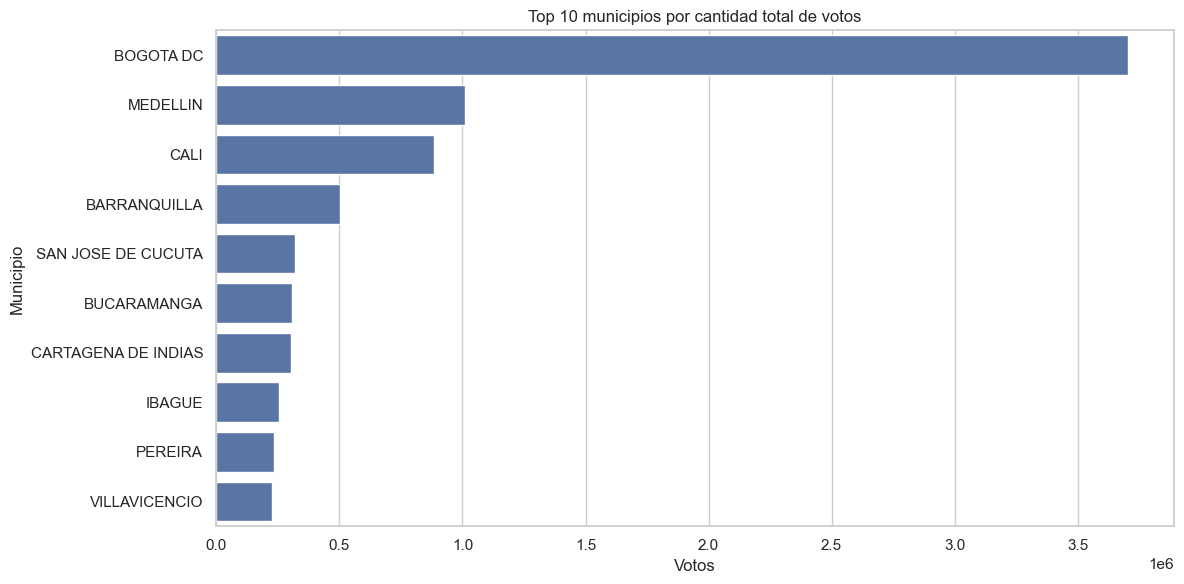

In [20]:
top_municipalities = municipality_votes.head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_municipalities,
    x="votos",
    y="municipio"
)
ax.set_title("Top 10 municipios por cantidad total de votos")
ax.set_xlabel("Votos")
ax.set_ylabel("Municipio")
plt.tight_layout()
plt.savefig(IMAGES_PATH / "05_top_municipios.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Comparación de candidatos en las principales ciudades

In [21]:
top_cities = [
    "BOGOTA DC",
    "MEDELLIN",
    "CALI",
    "BARRANQUILLA",
    "SAN JOSE DE CUCUTA",
]

city_results = (
    df[
        (df["municipio"].isin(top_cities))
        & (df["tipo_registro"] == "Candidato")
    ]
    .groupby(["municipio", "candidato"], as_index=False)["votos"]
    .sum()
)

city_results

,municipio,candidato,votos
0,BARRANQUILLA,DE LA CALLE LOMBANA HUMBERTO,8635
1,BARRANQUILLA,DUQUE MARQUEZ IVAN,144321
2,BARRANQUILLA,FAJARDO VALDERRAMA SERGIO,63348
3,BARRANQUILLA,MORALES HOYOS VIVIANE ALEIDA,933
4,BARRANQUILLA,PETRO URREGO GUSTAVO FRANCISCO,188185
5,BARRANQUILLA,TRUJILLO SARMIENTO JORGE ANTONIO,1958
6,BARRANQUILLA,VARGAS LLERAS GERMAN,79653
7,BOGOTA DC,DE LA CALLE LOMBANA HUMBERTO,93401
8,BOGOTA DC,DUQUE MARQUEZ IVAN,989744
9,BOGOTA DC,FAJARDO VALDERRAMA SERGIO,1244477


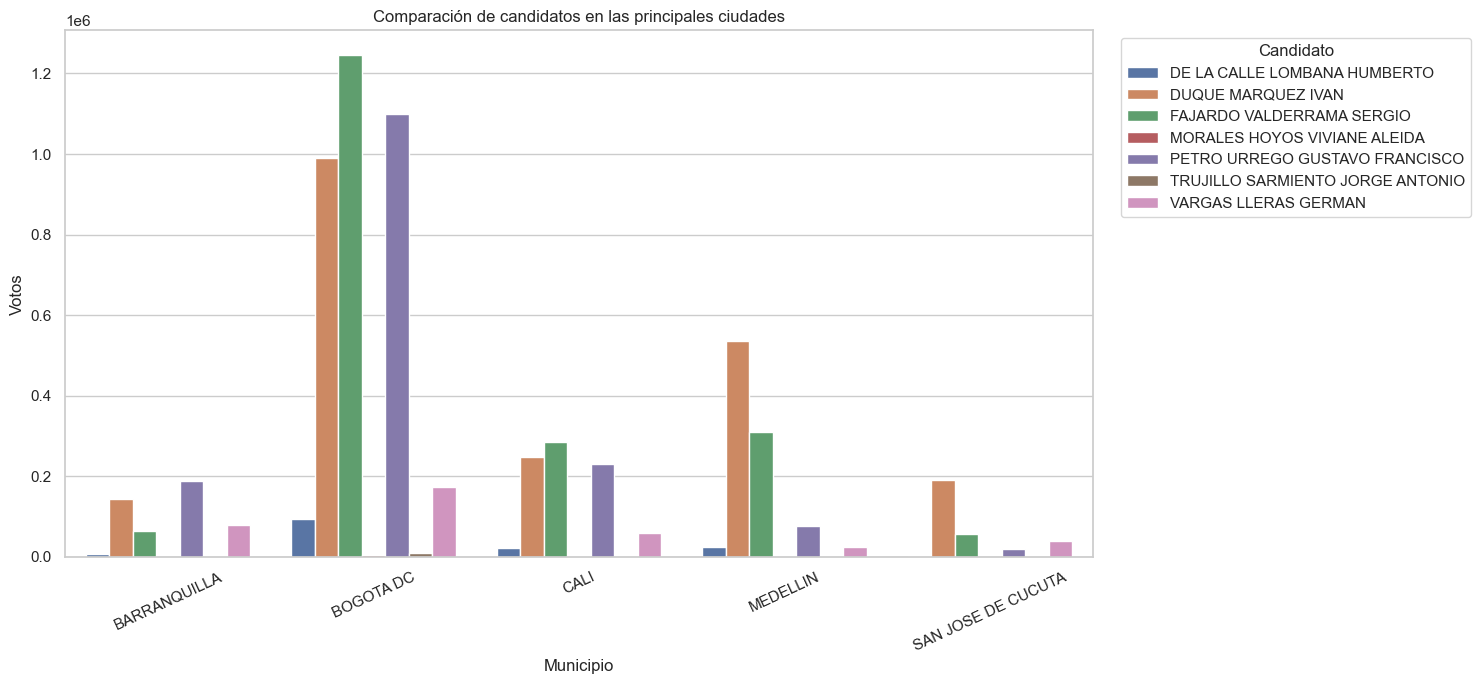

In [22]:
plt.figure(figsize=(15, 7))
ax = sns.barplot(
    data=city_results,
    x="municipio",
    y="votos",
    hue="candidato"
)
ax.set_title("Comparación de candidatos en las principales ciudades")
ax.set_xlabel("Municipio")
ax.set_ylabel("Votos")
plt.xticks(rotation=25)
plt.legend(title="Candidato", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(IMAGES_PATH / "06_comparacion_ciudades.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Ganador y margen de victoria por municipio

In [23]:
municipality_candidate = (
    df[df["tipo_registro"] == "Candidato"]
    .groupby(
        ["departamento", "municipio", "candidato"],
        as_index=False
    )["votos"]
    .sum()
)

municipality_ranked = municipality_candidate.sort_values(
    ["departamento", "municipio", "votos"],
    ascending=[True, True, False]
)

municipality_ranked["posicion"] = (
    municipality_ranked
    .groupby(["departamento", "municipio"])
    .cumcount() + 1
)

municipality_top_two = municipality_ranked[
    municipality_ranked["posicion"].isin([1, 2])
].copy()

municipality_top_two.head()

,departamento,municipio,candidato,votos,posicion
4,AMAZONAS,EL ENCANTO,PETRO URREGO GUSTAVO FRANCISCO,190,1
1,AMAZONAS,EL ENCANTO,DUQUE MARQUEZ IVAN,50,2
10,AMAZONAS,LA CHORRERA,PETRO URREGO GUSTAVO FRANCISCO,470,1
8,AMAZONAS,LA CHORRERA,DUQUE MARQUEZ IVAN,44,2
15,AMAZONAS,LA PEDRERA,PETRO URREGO GUSTAVO FRANCISCO,150,1


In [24]:
municipality_pivot = municipality_top_two.pivot(
    index=["departamento", "municipio"],
    columns="posicion",
    values=["candidato", "votos"]
)

municipality_margins = pd.DataFrame({
    "departamento": municipality_pivot.index.get_level_values(0),
    "municipio": municipality_pivot.index.get_level_values(1),
    "ganador": municipality_pivot[("candidato", 1)].values,
    "segundo": municipality_pivot[("candidato", 2)].values,
    "votos_ganador": municipality_pivot[("votos", 1)].astype(float).values,
    "votos_segundo": municipality_pivot[("votos", 2)].astype(float).values,
})

municipality_margins["margen_votos"] = (
    municipality_margins["votos_ganador"]
    - municipality_margins["votos_segundo"]
)

municipality_margins["total_top_2"] = (
    municipality_margins["votos_ganador"]
    + municipality_margins["votos_segundo"]
)

municipality_margins["margen_porcentual"] = (
    municipality_margins["margen_votos"]
    / municipality_margins["total_top_2"]
    * 100
)

municipality_margins.sort_values("margen_porcentual").head(15)

,departamento,municipio,ganador,segundo,votos_ganador,votos_segundo,margen_votos,total_top_2,margen_porcentual
525,CONSULADOS,GHANA,DUQUE MARQUEZ IVAN,FAJARDO VALDERRAMA SERGIO,4.00,4.00,0.00,8.00,0.00
947,PUTUMAYO,SAN FRANCISCO,PETRO URREGO GUSTAVO FRANCISCO,DUQUE MARQUEZ IVAN,835.00,834.00,1.00,"1,669.00",0.06
321,BOYACA,TIBASOSA,FAJARDO VALDERRAMA SERGIO,DUQUE MARQUEZ IVAN,"1,640.00","1,638.00",2.00,"3,278.00",0.06
475,CHOCO,CERTEGUI,PETRO URREGO GUSTAVO FRANCISCO,DUQUE MARQUEZ IVAN,644.00,643.00,1.00,"1,287.00",0.08
577,CORDOBA,MOMIL,DUQUE MARQUEZ IVAN,PETRO URREGO GUSTAVO FRANCISCO,"2,741.00","2,735.00",6.00,"5,476.00",0.11
578,CORDOBA,MONITOS,DUQUE MARQUEZ IVAN,PETRO URREGO GUSTAVO FRANCISCO,"2,832.00","2,824.00",8.00,"5,656.00",0.14
880,NARINO,POTOSI,PETRO URREGO GUSTAVO FRANCISCO,DUQUE MARQUEZ IVAN,"1,360.00","1,355.00",5.00,"2,715.00",0.18
840,NARINO,BARBACOAS,DUQUE MARQUEZ IVAN,PETRO URREGO GUSTAVO FRANCISCO,"1,552.00","1,543.00",9.00,"3,095.00",0.29
1085,SUCRE,SAN LUIS DE SINCE,PETRO URREGO GUSTAVO FRANCISCO,DUQUE MARQUEZ IVAN,"5,396.00","5,360.00",36.00,"10,756.00",0.33
195,BOLIVAR,SAN CRISTOBAL,PETRO URREGO GUSTAVO FRANCISCO,VARGAS LLERAS GERMAN,"1,065.00","1,057.00",8.00,"2,122.00",0.38


## 12. Identificación exploratoria de municipios atípicos

Se usa el rango intercuartílico (IQR) sobre el total de votos municipales. Este procedimiento no demuestra irregularidades electorales; únicamente detecta municipios cuyo volumen se aparta considerablemente del conjunto.

In [25]:
q1 = municipality_votes["votos"].quantile(0.25)
q3 = municipality_votes["votos"].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

municipality_votes["atipico_volumen"] = (
    municipality_votes["votos"] > upper_limit
)

municipality_outliers = municipality_votes[
    municipality_votes["atipico_volumen"]
].copy()

print(f"Límite superior IQR: {upper_limit:,.0f} votos")
print(f"Municipios detectados: {len(municipality_outliers)}")
municipality_outliers.head(20)

Límite superior IQR: 19,036 votos
Municipios detectados: 127


,departamento,municipio,votos,atipico_volumen
168,BOGOTA DC,BOGOTA DC,3705960,True
79,ANTIOQUIA,MEDELLIN,1009878,True
1147,VALLE DEL CAUCA,CALI,883217,True
146,ATLANTICO,BARRANQUILLA,501970,True
931,NORTE DE SANTANDER,SAN JOSE DE CUCUTA,320722,True
987,SANTANDER,BUCARAMANGA,306948,True
177,BOLIVAR,CARTAGENA DE INDIAS,304264,True
1113,TOLIMA,IBAGUE,255315,True
974,RISARALDA,PEREIRA,234395,True
834,META,VILLAVICENCIO,225253,True


### Advertencia metodológica

Un valor atípico no equivale a fraude ni a error. En este caso, las grandes ciudades pueden aparecer como atípicas simplemente por su tamaño poblacional. El resultado debe interpretarse como una señal para investigar, no como una conclusión.

## 13. Concentración del voto por candidato

In [26]:
candidate_department_share = (
    department_candidate
    .merge(
        candidate_results[["candidato", "votos"]].rename(
            columns={"votos": "votos_nacionales"}
        ),
        on="candidato",
        how="left"
    )
)

candidate_department_share["participacion_nacional_candidato"] = (
    candidate_department_share["votos"]
    / candidate_department_share["votos_nacionales"]
    * 100
)

candidate_department_share.sort_values(
    "participacion_nacional_candidato",
    ascending=False
).head(15)

,departamento,candidato,votos,votos_nacionales,participacion_nacional_candidato
37,BOGOTA DC,FAJARDO VALDERRAMA SERGIO,1244477,4602916,27.04
35,BOGOTA DC,DE LA CALLE LOMBANA HUMBERTO,93401,396151,23.58
39,BOGOTA DC,PETRO URREGO GUSTAVO FRANCISCO,1099955,4854831,22.66
8,ANTIOQUIA,DUQUE MARQUEZ IVAN,1375965,7617114,18.06
40,BOGOTA DC,TRUJILLO SARMIENTO JORGE ANTONIO,10696,65767,16.26
9,ANTIOQUIA,FAJARDO VALDERRAMA SERGIO,732993,4602916,15.92
38,BOGOTA DC,MORALES HOYOS VIVIANE ALEIDA,5492,36138,15.20
7,ANTIOQUIA,DE LA CALLE LOMBANA HUMBERTO,59136,396151,14.93
36,BOGOTA DC,DUQUE MARQUEZ IVAN,989744,7617114,12.99
34,ATLANTICO,VARGAS LLERAS GERMAN,173129,1412392,12.26


## 14. Exportación de tablas para dashboard y documentación

In [27]:
exports_path = PROJECT_ROOT / "data" / "processed"
exports_path.mkdir(parents=True, exist_ok=True)

candidate_results.to_csv(
    exports_path / "candidate_results.csv",
    index=False
)
department_votes.to_csv(
    exports_path / "department_votes.csv",
    index=False
)
department_margins.to_csv(
    exports_path / "department_margins.csv",
    index=False
)
municipality_votes.to_csv(
    exports_path / "municipality_votes.csv",
    index=False
)
municipality_margins.to_csv(
    exports_path / "municipality_margins.csv",
    index=False
)
city_results.to_csv(
    exports_path / "city_results.csv",
    index=False
)

print("Tablas exportadas en:", exports_path)

Tablas exportadas en: d:\Sartocol87\Documentos\debsenior\ejercicios\elecciones\colombia-election-analysis-2018\data\processed


## 15. Conclusiones

- Los resultados nacionales deben analizarse por separado de votos blancos, nulos y tarjetas no marcadas.
- El número de departamentos ganados no reemplaza el análisis de votos absolutos ni porcentuales.
- Las principales ciudades muestran comportamientos electorales distintos.
- Los márgenes de victoria permiten distinguir territorios competitivos de territorios dominados por una candidatura.
- La detección de valores atípicos es exploratoria y no constituye evidencia de irregularidad.

## Siguientes extensiones

- incorporar datos de participación y potencial electoral;
- construir un mapa coroplético por departamento;
- comparar primera y segunda vuelta;
- añadir variables socioeconómicas;
- evaluar técnicas de clustering territorial.